In [52]:

%config InlineBackend.figure_format = 'retina'


In [53]:
from common import *

In [54]:
sizes = ["0.6B", "1.7B", "4B"]
css = ["32", "64", "128"]
model_labels = [f"{s}-{cs}" for cs in css for s in sizes]
models = [f"Qwen3-{label}" for label in model_labels]


def load_model(model_name):
    """Load trace data for a model."""
    return read_trace(f"{model_name}/1.csv")

In [55]:
# Load data for all models
dfs = {model: load_model(model) for model in models}

In [56]:
# Reuse the match_begin_end_events function from time_breakdown.ipynb
def match_begin_end_events(df, begin_type, end_type, event_type, end_cols=[], by_cols=[]):
    """Match begin and end events and calculate durations."""
    end_cols_list = ['timestamp_us'] + [c for c in end_cols if c in df.columns] + [c for c in by_cols if c in df.columns]
    begin_cols_list = ['timestamp_us'] + [c for c in by_cols if c in df.columns]
    ends = df[df['type'] == end_type][end_cols_list]
    begins = df[df['type'] == begin_type][begin_cols_list].rename(columns={'timestamp_us': 'begin_timestamp'})
    
    merged = pd.merge_asof(
        ends, begins,
        left_on='timestamp_us', right_on='begin_timestamp',
        by=by_cols if by_cols else None,
        direction='backward'
    )
    
    merged = merged.rename(columns={'timestamp_us': 'end_timestamp'})
    merged['duration_us'] = merged['end_timestamp'] - merged['begin_timestamp']
    merged['event_type'] = event_type
    return merged

In [57]:
# Extract checkpoint times for each model
checkpoint_data = {}
for model in models:
    checkpoint_df = match_begin_end_events(
        dfs[model], 'CheckpointBegin', 'CheckpointComplete', 'checkpoint', end_cols=['count']
    )
    checkpoint_df['model'] = model
    checkpoint_data[model] = checkpoint_df

checkpoint_all = pd.concat(checkpoint_data.values(), ignore_index=True)
checkpoint_all['duration_ms'] = checkpoint_all['duration_us'] / 1000

# Calculate average checkpoint time for each model
def mean_without_outliers(group):
    sorted_values = group.sort_values()
    if len(sorted_values) <= 2:
        return sorted_values.mean()
    # Remove smallest and largest
    trimmed = sorted_values.iloc[1:-1]
    return trimmed.mean()

checkpoint_avg = checkpoint_all.groupby('model')['duration_ms'].apply(mean_without_outliers).reset_index()
checkpoint_avg.columns = ['model', 'avg_checkpoint_ms']
print("Average Checkpoint Times by Model:")
print(checkpoint_avg.to_string(index=False))

Average Checkpoint Times by Model:
         model  avg_checkpoint_ms
Qwen3-0.6B-128          18.229238
 Qwen3-0.6B-32          10.570819
 Qwen3-0.6B-64          13.795319
Qwen3-1.7B-128          19.311348
 Qwen3-1.7B-32          12.999147
 Qwen3-1.7B-64          18.756105
  Qwen3-4B-128          27.561263
   Qwen3-4B-32          26.561880
   Qwen3-4B-64          50.898704


In [58]:
# Extract model loading times for each model
model_load_data = {}
for model in models:
    model_load_df = match_begin_end_events(
        dfs[model], 'ModelLoadBegin', 'ModelLoadComplete', 'model_load'
    )
    model_load_df['model'] = model
    model_load_data[model] = model_load_df

model_load_all = pd.concat(model_load_data.values(), ignore_index=True)
model_load_all['duration_ms'] = model_load_all['duration_us'] / 1000
model_load_all.head()

,end_timestamp,begin_timestamp,duration_us,event_type,model,duration_ms
0,2505312,1008085,1497227,model_load,Qwen3-0.6B-32,1497.227
1,4238517,1029504,3209013,model_load,Qwen3-1.7B-32,3209.013
2,7058060,1032331,6025729,model_load,Qwen3-4B-32,6025.729
3,2641286,1053472,1587814,model_load,Qwen3-0.6B-64,1587.814
4,4145415,1063170,3082245,model_load,Qwen3-1.7B-64,3082.245


In [59]:
# Extract per-layer inference times for each model
layer_data = {}
for model in models:
    layer_df = match_begin_end_events(
        dfs[model], "LayerBegin", "LayerComplete", "layer", 
        by_cols=["layer_idx", "seq_len", "token_idx"]
    )
    layer_df['model'] = model
    layer_data[model] = layer_df

layer_all = pd.concat(layer_data.values(), ignore_index=True)
layer_all['duration_ms'] = layer_all['duration_us'] / 1000

# Filter to only first 64 layer events per model (by timestamp order)
layer_all_first64 = layer_all.sort_values('end_timestamp').groupby('model').head(64)

# Calculate average per-layer inference time for each model (first 64 events only)
layer_avg = layer_all_first64.groupby('model')['duration_ms'].mean().reset_index()
layer_avg.columns = ['model', 'avg_layer_inference_ms']
print("Average Per-Layer Inference Times by Model (first 64 events only):")
print(layer_avg.to_string(index=False))

Average Per-Layer Inference Times by Model (first 64 events only):
         model  avg_layer_inference_ms
Qwen3-0.6B-128              171.345578
 Qwen3-0.6B-32               38.038266
 Qwen3-0.6B-64               79.632391
Qwen3-1.7B-128              462.935781
 Qwen3-1.7B-32              110.144875
 Qwen3-1.7B-64              226.387094
  Qwen3-4B-128              909.225125
   Qwen3-4B-32              216.953594
   Qwen3-4B-64              448.128953


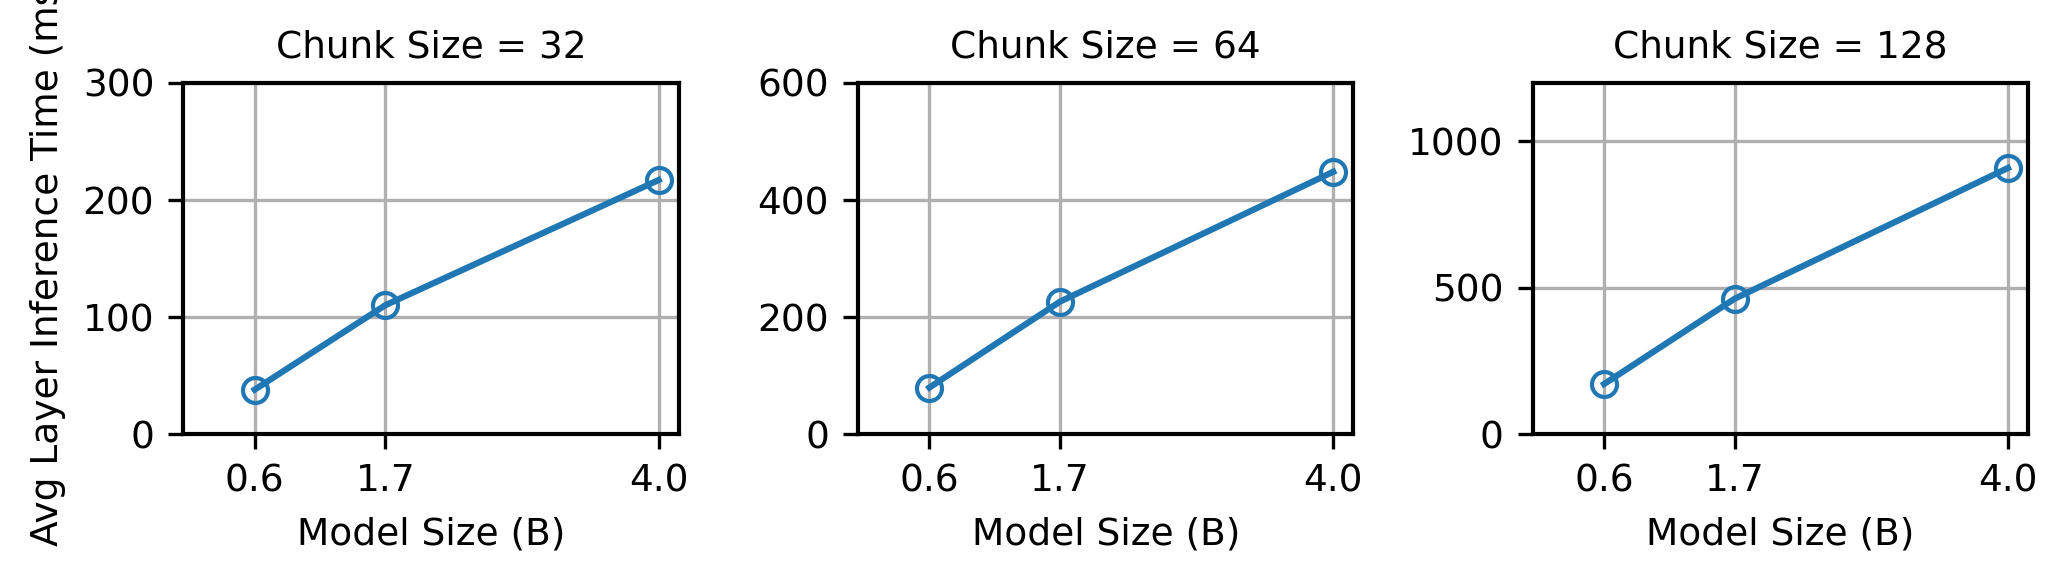

In [60]:
# Parse model names to extract size and chunk size
layer_avg['size'] = layer_avg['model'].str.extract(r'Qwen3-(\d+\.?\d*)B')[0].astype(float)
layer_avg['chunk_size'] = layer_avg['model'].str.extract(r'-(\d+)$')[0].astype(int)

# Create subplots - one for each chunk size
fig, axes = plt.subplots(1, len(css), figsize=(full_width, default_height))

for i, cs in enumerate(css):
    ax = axes[i]
    data = layer_avg[layer_avg['chunk_size'] == int(cs)].sort_values('size')
    
    ax.plot(data['size'], data['avg_layer_inference_ms'], 
            marker='o', linestyle='-', linewidth=1.5, markersize=6)
    ax.set_xlabel('Model Size (B)')
    ax.set_ylabel('Avg Layer Inference Time (ms)' if i == 0 else '')
    ax.set_title(f'Chunk Size = {cs}')
    ax.set_xticks(data['size'])
    ax.set_xticklabels([f'{s:.1f}' for s in data['size']])
    ax.set_ylim(0, 300 * int(cs) / 32)
    ax.set_xlim(0, None)

plt.tight_layout()
plt.show()

Average Model Loading Times by Model:
         model  avg_model_load_ms  size  chunk_size
Qwen3-0.6B-128            1541.86   0.6         128
 Qwen3-0.6B-32           1497.227   0.6          32
 Qwen3-0.6B-64           1587.814   0.6          64
Qwen3-1.7B-128           3208.628   1.7         128
 Qwen3-1.7B-32           3209.013   1.7          32
 Qwen3-1.7B-64           3082.245   1.7          64
  Qwen3-4B-128           5887.241   4.0         128
   Qwen3-4B-32           6025.729   4.0          32
   Qwen3-4B-64           6170.082   4.0          64


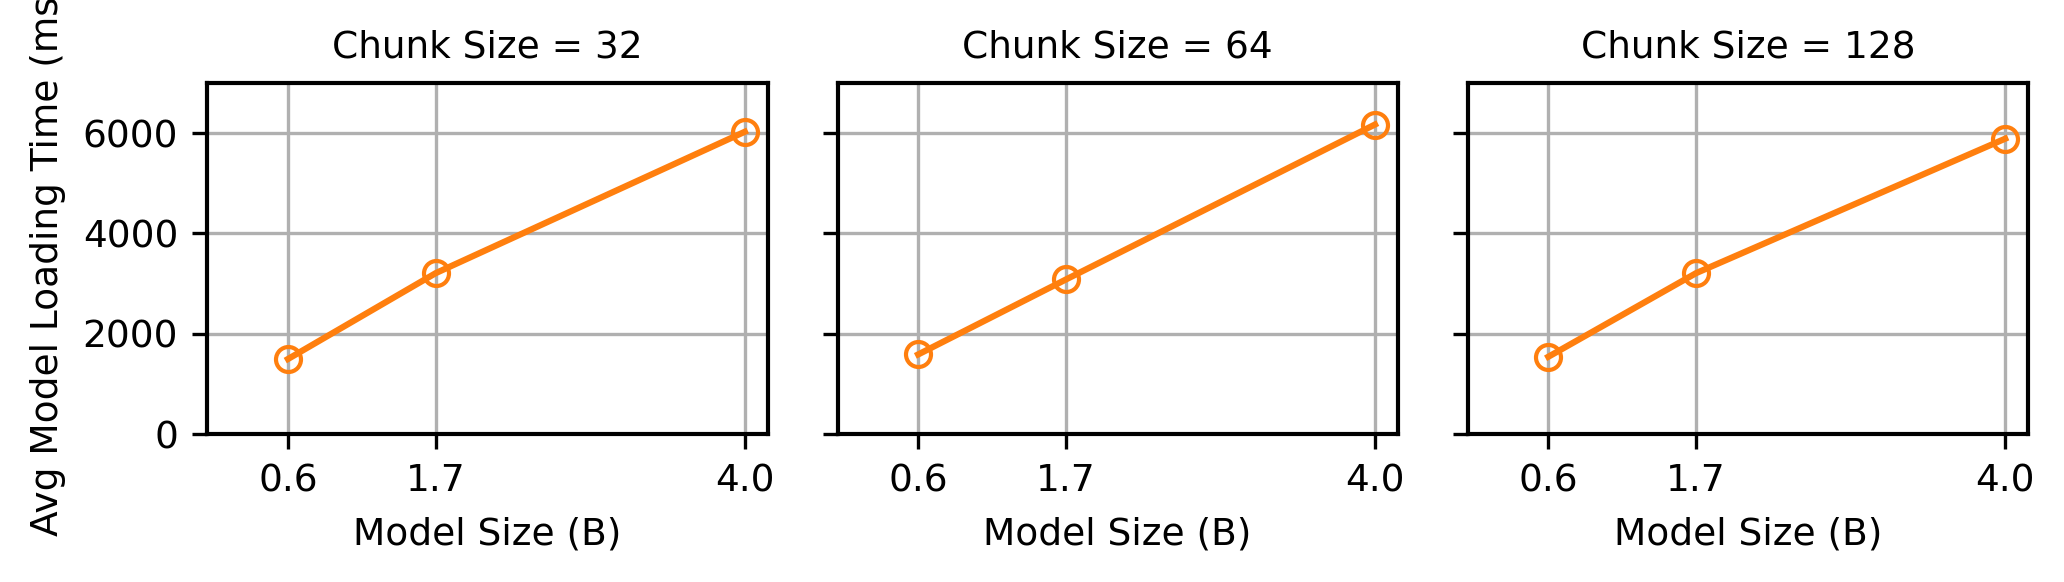

In [61]:
# Calculate average model loading time per model
model_load_avg = model_load_all.groupby('model')['duration_ms'].mean().reset_index()
model_load_avg.columns = ['model', 'avg_model_load_ms']

# Parse model names to extract size and chunk size
model_load_avg['size'] = model_load_avg['model'].str.extract(r'Qwen3-(\d+\.?\d*)B')[0].astype(float)
model_load_avg['chunk_size'] = model_load_avg['model'].str.extract(r'-(\d+)$')[0].astype(int)

print("Average Model Loading Times by Model:")
print(model_load_avg.to_string(index=False))

# Create subplots - one for each chunk size
fig, axes = plt.subplots(1, len(css), figsize=(full_width, default_height), sharey=True)

for i, cs in enumerate(css):
    ax = axes[i]
    data = model_load_avg[model_load_avg['chunk_size'] == int(cs)].sort_values('size')
    
    ax.plot(data['size'], data['avg_model_load_ms'], 
            marker='o', linestyle='-', linewidth=1.5, markersize=6, color='C1')
    ax.set_xlabel('Model Size (B)')
    ax.set_ylabel('Avg Model Loading Time (ms)' if i == 0 else '')
    ax.set_title(f'Chunk Size = {cs}')
    ax.set_xticks(data['size'])
    ax.set_xticklabels([f'{s:.1f}' for s in data['size']])
    ax.set_ylim(0, 7000)
    ax.set_xlim(0, None)

plt.tight_layout()
plt.show()

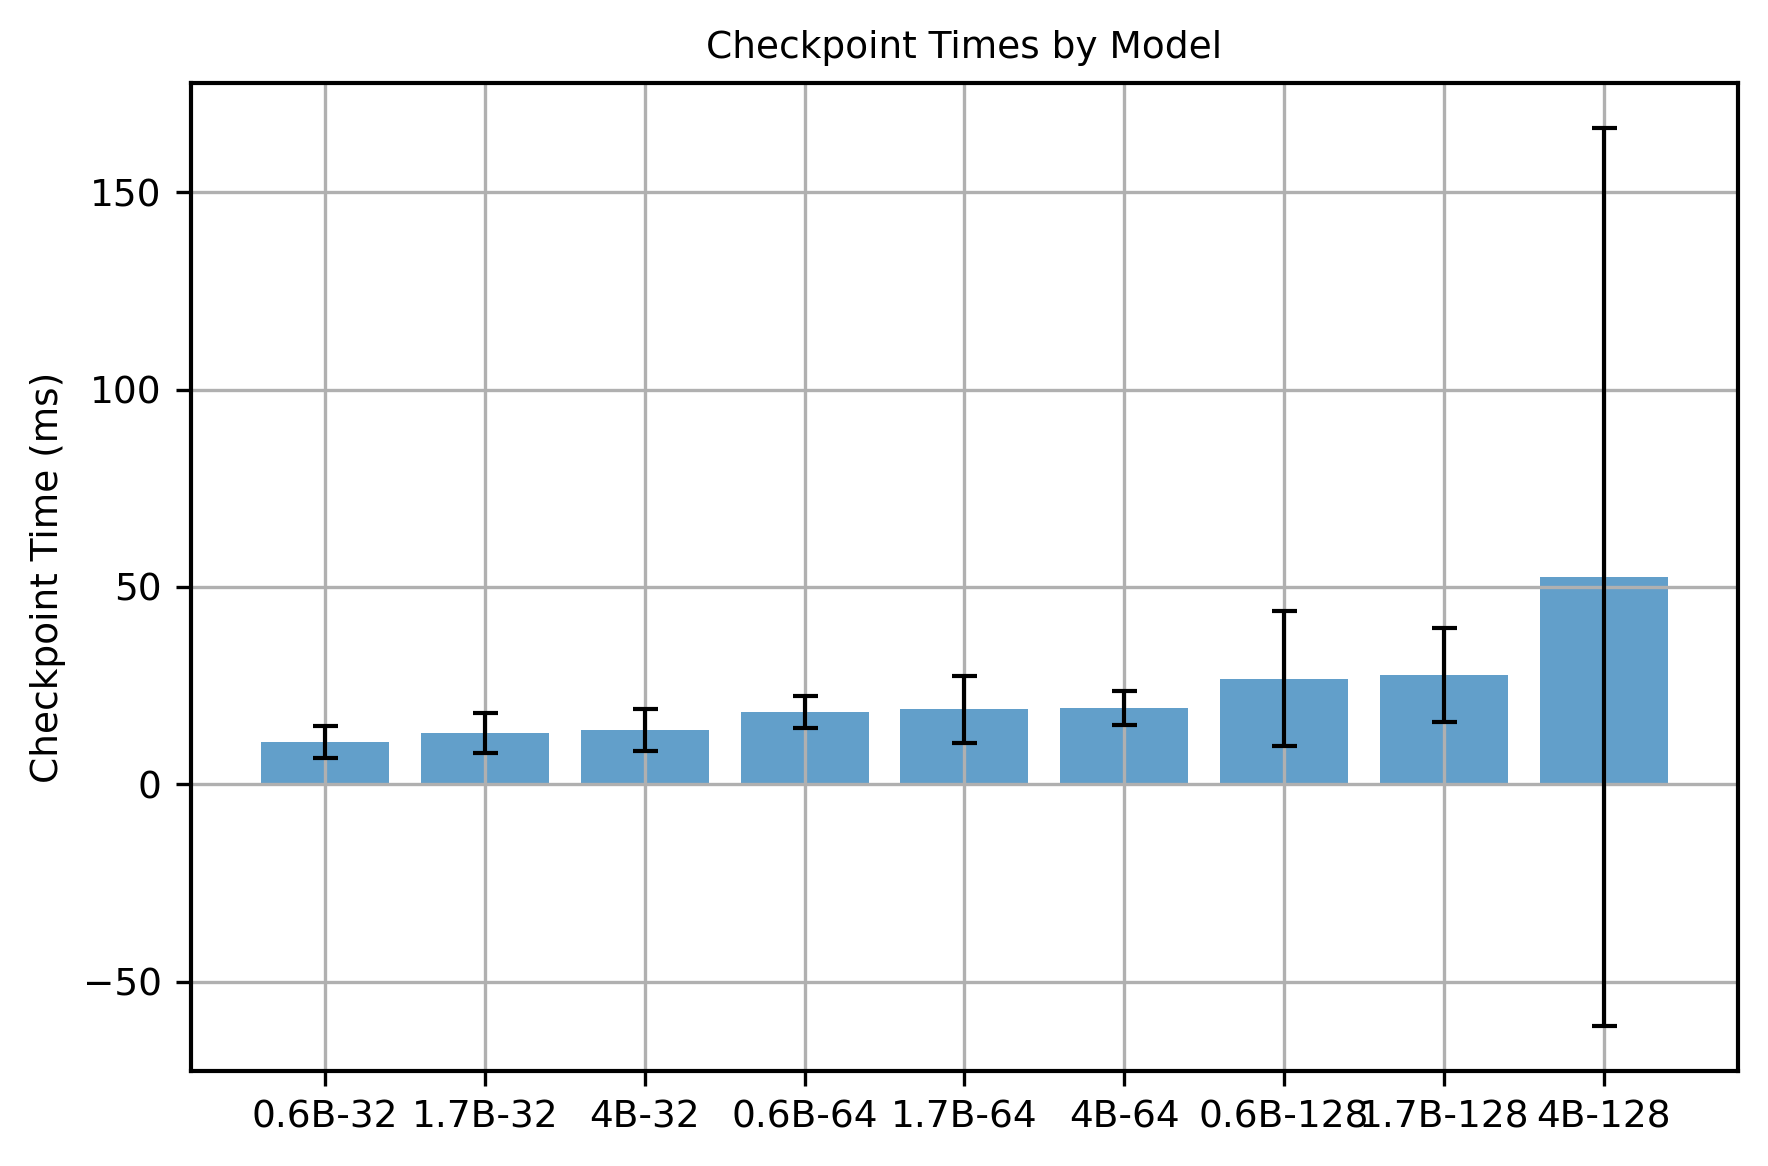

Checkpoint Times Summary:
            model       mean         std    min      max
1   Qwen3-0.6B-32  10.613563    4.041209    3.5   34.953
4   Qwen3-1.7B-32  13.010868    5.165159  3.563   28.741
2   Qwen3-0.6B-64  13.844556    5.323556  3.626   35.486
0  Qwen3-0.6B-128  18.223139    4.049321  3.587   29.401
5   Qwen3-1.7B-64  18.963175    8.424704  3.589  185.498
3  Qwen3-1.7B-128  19.320922    4.336015  3.584   41.214
7     Qwen3-4B-32  26.731098   17.124264  3.716  217.103
6    Qwen3-4B-128  27.628515   11.894286  3.836   64.737
8     Qwen3-4B-64  52.528628  113.764195  3.771  684.799


In [62]:
# Compare checkpoint times
fig, ax = plt.subplots(figsize=(6, 4))

checkpoint_summary = checkpoint_all.groupby('model')['duration_ms'].agg(['mean', 'std', 'min', 'max']).reset_index()
checkpoint_summary = checkpoint_summary.sort_values('mean')

x_pos = np.arange(len(checkpoint_summary))
ax.bar(x_pos, checkpoint_summary['mean'], yerr=checkpoint_summary['std'], 
       capsize=3, alpha=0.7, color='C0')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_labels)
ax.set_ylabel('Checkpoint Time (ms)')
ax.set_title('Checkpoint Times by Model')
plt.tight_layout()
plt.show()

print("Checkpoint Times Summary:")
print(checkpoint_summary)

TypeError: boolean value of NA is ambiguous

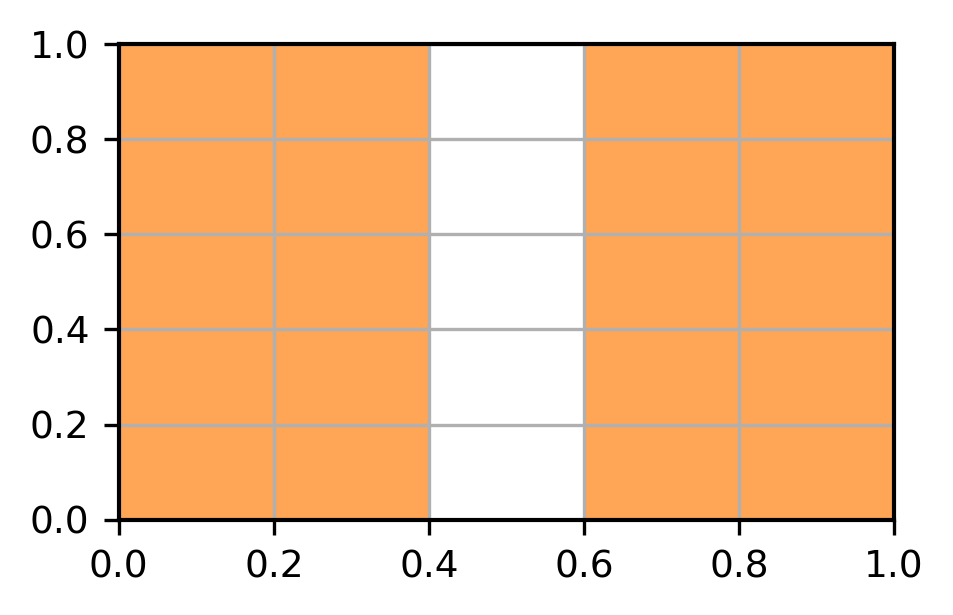

In [63]:
# Compare model loading times
fig, ax = plt.subplots(figsize=figsize)

model_load_summary = model_load_all.groupby('model')['duration_ms'].agg(['mean', 'std', 'min', 'max']).reset_index()
model_load_summary = model_load_summary.sort_values('mean')

x_pos = np.arange(len(model_load_summary))
ax.bar(x_pos, model_load_summary['mean'], yerr=model_load_summary['std'], 
       capsize=3, alpha=0.7, color='C1')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_load_summary['model'], rotation=45, ha='right')
ax.set_ylabel('Model Loading Time (ms)')
ax.set_title('Model Loading Times by Model')
plt.tight_layout()
plt.show()

print("Model Loading Times Summary:")
print(model_load_summary)

In [ ]:
# Compare per-layer inference times
# Group by model and layer_idx, then compute average per layer
layer_summary = layer_all.groupby(['model', 'layer_idx'])['duration_ms'].mean().reset_index()

fig, ax = plt.subplots(figsize=figsize)

for i, model in enumerate(models):
    model_layers = layer_summary[layer_summary['model'] == model]
    ax.plot(model_layers['layer_idx'], model_layers['duration_ms'], 
            marker=marker_list[i % len(marker_list)], 
            linestyle=linestyles[i % len(linestyles)],
            label=model, linewidth=1.5, markersize=4)

ax.set_xlabel('Layer Index')
ax.set_ylabel('Average Layer Inference Time (ms)')
ax.set_title('Per-Layer Inference Times by Model')
ax.legend()
plt.tight_layout()
plt.show()

# Print summary statistics
print("Per-Layer Inference Times Summary:")
for model in models:
    model_layers = layer_summary[layer_summary['model'] == model]
    print(f"\n{model}:")
    print(f"  Mean: {model_layers['duration_ms'].mean():.2f} ms")
    print(f"  Std: {model_layers['duration_ms'].std():.2f} ms")
    print(f"  Min: {model_layers['duration_ms'].min():.2f} ms")
    print(f"  Max: {model_layers['duration_ms'].max():.2f} ms")
    print(f"  Total layers: {len(model_layers)}")

In [ ]:
# Overall comparison: total inference time per model (sum of all layer times)
total_inference = layer_all.groupby('model')['duration_ms'].sum().reset_index()
total_inference.columns = ['model', 'total_inference_ms']

# Combine all metrics for side-by-side comparison
comparison = pd.merge(
    checkpoint_summary[['model', 'mean']].rename(columns={'mean': 'checkpoint_ms'}),
    model_load_summary[['model', 'mean']].rename(columns={'mean': 'model_load_ms'}),
    on='model'
)
comparison = pd.merge(
    comparison,
    total_inference,
    on='model'
)

print("Overall Comparison:")
print(comparison.to_string(index=False))

In [ ]:
# Create a combined comparison plot
fig, axes = plt.subplots(1, 3, figsize=(full_width, default_height))

# Checkpoint times
checkpoint_summary = checkpoint_summary.sort_values('mean')
x_pos = np.arange(len(checkpoint_summary))
axes[0].bar(x_pos, checkpoint_summary['mean'], yerr=checkpoint_summary['std'], 
            capsize=3, alpha=0.7, color='C0')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(checkpoint_summary['model'], rotation=45, ha='right')
axes[0].set_ylabel('Time (ms)')
axes[0].set_title('Checkpoint Times')

# Model loading times
model_load_summary = model_load_summary.sort_values('mean')
x_pos = np.arange(len(model_load_summary))
axes[1].bar(x_pos, model_load_summary['mean'], yerr=model_load_summary['std'], 
            capsize=3, alpha=0.7, color='C1')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_load_summary['model'], rotation=45, ha='right')
axes[1].set_ylabel('Time (ms)')
axes[1].set_title('Model Loading Times')

# Average layer inference time
layer_avg = layer_all.groupby('model')['duration_ms'].agg(['mean', 'std']).reset_index()
layer_avg = layer_avg.sort_values('mean')
x_pos = np.arange(len(layer_avg))
axes[2].bar(x_pos, layer_avg['mean'], yerr=layer_avg['std'], 
            capsize=3, alpha=0.7, color='C2')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(layer_avg['model'], rotation=45, ha='right')
axes[2].set_ylabel('Time (ms)')
axes[2].set_title('Avg Layer Inference Time')

plt.tight_layout()
plt.show()